<a href="https://colab.research.google.com/github/fisherat/CSFinalProjectSp26/blob/main/fishera_FD_CSFinalPrj_ChemLibretextsClusterAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Load the webscraped csv in this file
  #from google.colab import drive
  #drive.mount('/content/drive', force_remount=True)
  #libretexts = pd.read_csv('/content/drive/MyDrive/CS-215/Data/libretexts_data.csv')

libretexts = pd.read_csv('libretexts_data.csv')

#Import relevant packages - Dealing with dataframes
import pandas as pd

#Import relevant packages - Visualizing 2D Numeric Analysis
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Import relevant packages - Webscraping
import requests
from bs4 import BeautifulSoup
import re
import string
import textstat

#Import relevant packages - Principal Component Analysis - Mathematical computation of linearized variance
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#Import relevant packages - Cluster Analysis
from scipy.cluster.vq import kmeans, vq

#Import relevant packages - 3D, interactive plots
import plotly.express as px

#Install Natural Language Processing for a better understanding of the text
!pip install textstat

#Examine the imported DataFrame
libretexts.head()

,chapter_title,unit_title,unit_link,specialty,mean_score,median_score,word_count,figure_count
0,1: Essential Ideas,1.0: Introduction,https://chem.libretexts.org/Bookshelves/Genera...,General,0.54,0.528571,339,1
1,1: Essential Ideas,1.1: Chemistry in Context,https://chem.libretexts.org/Bookshelves/Genera...,General,0.54,0.528571,1741,5
2,1: Essential Ideas,1.2: Phases and Classification of Matter,https://chem.libretexts.org/Bookshelves/Genera...,General,0.54,0.528571,2871,13
3,1: Essential Ideas,1.3: Physical and Chemical Properties,https://chem.libretexts.org/Bookshelves/Genera...,General,0.54,0.528571,1012,6
4,1: Essential Ideas,1.4: Measurements,https://chem.libretexts.org/Bookshelves/Genera...,General,0.54,0.528571,2099,4


The optimal number of clusters is 3


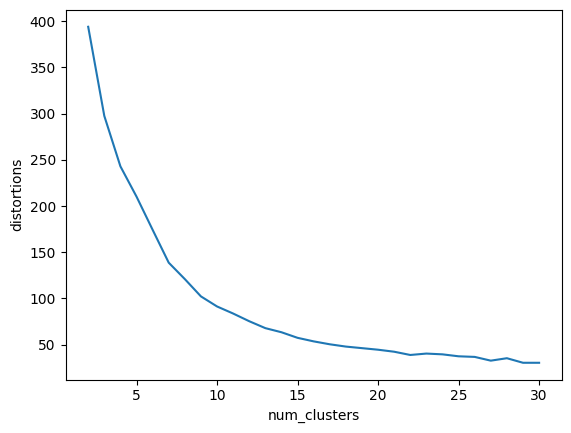

In [ ]:
#Cluster Analysis - k-means via scipy
##Run clustering algorithm for mean ACS score vs word count

#Run the kmeans distortion algorithm to assess intervariable variance
distortions = []
numclusters = range(2,31)
for k in numclusters:
    cluster_centers, distortion = kmeans(libretexts[['mean_score', 'word_count', 'figure_count']], k)
    distortions.append(distortion)

#Optimize # of clusters by assessing the rate of change in distortions per # of clusters
distortion_data = pd.DataFrame({'num_clusters': numclusters, 'distortions': distortions})
distortion_data['del'] = distortion_data['distortions'].diff()
opt = distortion_data.loc[distortion_data['del'].idxmin(), 'num_clusters']
print("The optimal number of clusters is "+ str(opt))

#And plot the optimization
sns.lineplot(x='num_clusters', y='distortions', data=distortion_data)
plt.show()


In [ ]:
#Now we can build our initial 3D plot of the clusters using plotly

#Run the clustering algorithm with the optimal number of clusters for initial analysis @ 20 iterations
cluster_centers, distortion = kmeans(libretexts[['mean_score', 'word_count', 'figure_count']], opt, iter = 20)

#Append the dataframe with the information from kmeans
libretexts['cluster_labels'], distortion_list = vq(libretexts[['mean_score', 'word_count', 'figure_count']], cluster_centers)

#Build the cluster plot with the appropriate information
i_plot = px.scatter_3d(data_frame=libretexts, x='mean_score', y='word_count', z='figure_count', color='cluster_labels',
                       #Allow hovering to detail the chapter information
                       hover_name='unit_title',
                       #Name the axis more legibly rather than with variables
                       labels={'mean_score': 'Mean ACS Score', 'word_count': 'Unit Word Count', 'figure_count': 'Unit Figure Count'}
               )
#Size the markers appropriately so the numbers are legible
i_plot.update_traces(marker=dict(size=3))

#Show the plot
i_plot.show()

In [ ]:
#Clean the text, prepare it for NLP analysis
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    # Remove punctuation
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    # Replace multiple spaces with a single space
    text = re.sub(r'\s+', ' ', text).strip()
    return text

#Build a function to webscrape and run NLP on the units from libretext
def get_content_from_link(unit_url):
    #Caution never hurts and we want to make sure our dataframe is getting the proper information, so we use try and except to detail what failed in our runs
    #This function can raise a number of errors if the internet connection is poor, so we need to know when we encounter a timeout
    try:
        response = requests.get(unit_url, timeout=10)
        response.raise_for_status() # Raise HTTPError for bad responses (4xx or 5xx)
        soup = BeautifulSoup(response.content, 'html.parser')

        # Find the main content div
        main_content_div = soup.find('div', id='main_content')
        if main_content_div:
            text_content = main_content_div.get_text()
        else:
            text_content = soup.get_text() # Fallback to full text if main_content not found

        return text_content # Only return text content
    except requests.exceptions.RequestException as e:
        print(f"Error fetching {unit_url}: {e}")
        return "" # Return empty string in case of error

# Handle cases where textstat might error out on empty or very short strings
def get_readability_score(text):
    if not text or len(text.split()) < 5: # textstat might require a minimum word count
        return 0.0 # Assign a default score for unanalyzable texts
    try:
        return textstat.flesch_kincaid_grade(text)
    except Exception:
        return 0.0 # Fallback for any other error

#Detail why the webscraping takes forever for the dear future readers
print("Fetching raw text content from unit links (this may take a while)...")
# Apply the scraping function to get raw_text.
libretexts['raw_text'] = libretexts['unit_link'].apply(get_content_from_link)

print("Cleaning text and calculating readability scores...")
libretexts['cleaned_text'] = libretexts['raw_text'].apply(clean_text)
libretexts['readability_score'] = libretexts['cleaned_text'].apply(get_readability_score)

#Drop raw_text and cleaned_text columns to save memory (VERY IMPORTANT)
libretexts.drop(columns=['raw_text', 'cleaned_text'], inplace=True)

#Detail when the webscraping is complete
print("Content metric and readability calculation complete.")
display(libretexts.head())

Fetching raw text content from unit links (this may take a while)...
Cleaning text and calculating readability scores...
Content metric and readability calculation complete.


,chapter_title,unit_title,unit_link,specialty,mean_score,median_score,word_count,figure_count,readability_score,cluster_labels
0,1: Essential Ideas,1.0: Introduction,https://chem.libretexts.org/Bookshelves/Genera...,General,0.54,0.528571,339,1,389.119872,2
1,1: Essential Ideas,1.1: Chemistry in Context,https://chem.libretexts.org/Bookshelves/Genera...,General,0.54,0.528571,1741,5,1051.229869,0
2,1: Essential Ideas,1.2: Phases and Classification of Matter,https://chem.libretexts.org/Bookshelves/Genera...,General,0.54,0.528571,2871,13,1626.685968,1
3,1: Essential Ideas,1.3: Physical and Chemical Properties,https://chem.libretexts.org/Bookshelves/Genera...,General,0.54,0.528571,1012,6,760.709080,2
4,1: Essential Ideas,1.4: Measurements,https://chem.libretexts.org/Bookshelves/Genera...,General,0.54,0.528571,2099,4,1249.030063,0


In [ ]:
# Calculate the means for a table made in excel
mean_word_count_per_specialty = libretexts.groupby('specialty')['word_count'].mean().reset_index()
mean_figure_count_per_specialty = libretexts.groupby('specialty')['figure_count'].mean().reset_index()
mean_readability_per_specialty = libretexts.groupby('specialty')['readability_score'].mean().reset_index()

display(mean_word_count_per_specialty)
display(mean_figure_count_per_specialty)
display(mean_readability_per_specialty)

,specialty,word_count
0,Analytical & Instrumental,1292.870130
1,General,1618.064815
2,Inorganic,823.593023
3,Organic,603.069351
4,Physical & Theoretical,1073.131098


,specialty,figure_count
0,Analytical & Instrumental,4.233766
1,General,5.185185
2,Inorganic,5.976744
3,Organic,7.516779
4,Physical & Theoretical,2.295732


,specialty,readability_score
0,Analytical & Instrumental,832.260617
1,General,988.017204
2,Inorganic,630.955272
3,Organic,530.333212
4,Physical & Theoretical,735.327372


Explained variance ratio by principal components: [0.56909039 0.43090961]


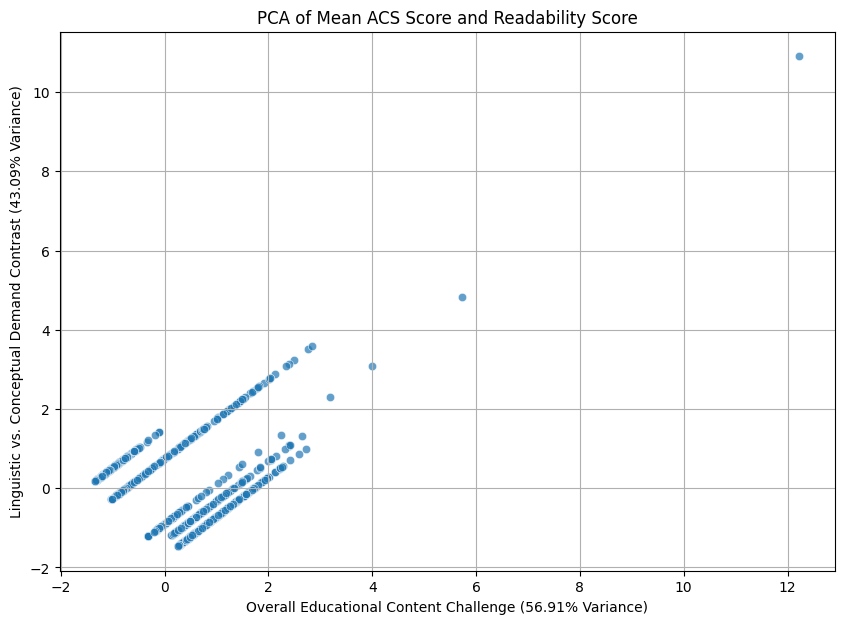

In [ ]:
# Prepare data for PCA: mean_score and readability_score
# Filter out rows with 0.0 readability score, as it's a placeholder for unanalyzable text
pca_data = libretexts[libretexts['readability_score'] > 0.0][['mean_score', 'readability_score']].copy()

# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pca_data)

# Apply PCA
pca = PCA(n_components=2) # We want 2 components from our 2 features
pca_components = pca.fit_transform(scaled_data)

# Create a DataFrame for the PCA results
pca_df = pd.DataFrame(data = pca_components, columns = ['principal_component_1', 'principal_component_2'])

# Add back original index for merging if needed, or relevant info for plotting
pca_df.index = pca_data.index

print(f"Explained variance ratio by principal components: {pca.explained_variance_ratio_}")

# Visualize PCA results
plt.figure(figsize=(10, 7))
sns.scatterplot(x='principal_component_1', y='principal_component_2', data=pca_df, alpha=0.7)
plt.title('PCA of Mean ACS Score and Readability Score')
plt.xlabel(f'Overall Educational Content Challenge ({pca.explained_variance_ratio_[0]*100:.2f}% Variance)')
plt.ylabel(f'Linguistic vs. Conceptual Demand Contrast ({pca.explained_variance_ratio_[1]*100:.2f}% Variance)')
plt.grid(True)
plt.show()

In [ ]:
# Merge PCA components back into the libretexts DataFrame
# Ensure that the index is aligned, handling potential filtering from pca_data
libretexts_with_pca = libretexts.loc[pca_df.index].copy()
libretexts_with_pca = pd.merge(libretexts_with_pca, pca_df, left_index=True, right_index=True, how='left')

# Display head to confirm merge
display(libretexts_with_pca.head())

,chapter_title,unit_title,unit_link,specialty,mean_score,median_score,word_count,figure_count,readability_score,principal_component_1,principal_component_2
0,1: Essential Ideas,1.0: Introduction,https://chem.libretexts.org/Bookshelves/Genera...,General,0.54,0.528571,339,1,389.119872,-0.868946,-0.119709
1,1: Essential Ideas,1.1: Chemistry in Context,https://chem.libretexts.org/Bookshelves/Genera...,General,0.54,0.528571,1741,5,1051.229869,0.150857,0.900094
2,1: Essential Ideas,1.2: Phases and Classification of Matter,https://chem.libretexts.org/Bookshelves/Genera...,General,0.54,0.528571,2871,13,1626.685968,1.037193,1.786430
3,1: Essential Ideas,1.3: Physical and Chemical Properties,https://chem.libretexts.org/Bookshelves/Genera...,General,0.54,0.528571,1012,6,760.709080,-0.296613,0.452624
4,1: Essential Ideas,1.4: Measurements,https://chem.libretexts.org/Bookshelves/Genera...,General,0.54,0.528571,2099,4,1249.030063,0.455515,1.204752


Now that the PCA components are merged, we can determine the optimal number of clusters for the new feature set and perform clustering.

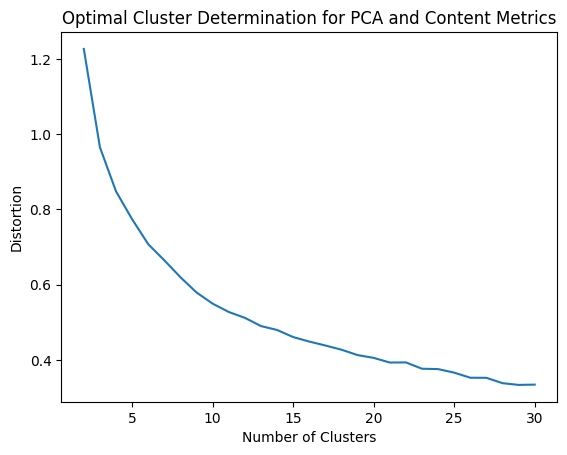

Optimal number of clusters for new features: 3


,chapter_title,unit_title,unit_link,specialty,mean_score,median_score,word_count,figure_count,readability_score,principal_component_1,principal_component_2,new_cluster_labels
0,1: Essential Ideas,1.0: Introduction,https://chem.libretexts.org/Bookshelves/Genera...,General,0.54,0.528571,339,1,389.119872,-0.868946,-0.119709,1
1,1: Essential Ideas,1.1: Chemistry in Context,https://chem.libretexts.org/Bookshelves/Genera...,General,0.54,0.528571,1741,5,1051.229869,0.150857,0.900094,1
2,1: Essential Ideas,1.2: Phases and Classification of Matter,https://chem.libretexts.org/Bookshelves/Genera...,General,0.54,0.528571,2871,13,1626.685968,1.037193,1.786430,2
3,1: Essential Ideas,1.3: Physical and Chemical Properties,https://chem.libretexts.org/Bookshelves/Genera...,General,0.54,0.528571,1012,6,760.709080,-0.296613,0.452624,1
4,1: Essential Ideas,1.4: Measurements,https://chem.libretexts.org/Bookshelves/Genera...,General,0.54,0.528571,2099,4,1249.030063,0.455515,1.204752,2


In [ ]:
# Define new features for clustering
features_for_new_clustering = ['principal_component_1', 'principal_component_2', 'word_count', 'figure_count']

# Filter out rows where word_count or figure_count might be 0 due to errors, or where PCA components are NaN
clustering_data = libretexts_with_pca[libretexts_with_pca['word_count'] > 0][features_for_new_clustering].dropna()

# Scale the data for clustering
scaler_clustering = StandardScaler()
scaled_clustering_data = scaler_clustering.fit_transform(clustering_data)

# Optimize number of clusters for the new feature set
new_distortions = []
new_numclusters = range(2, 31)
for k in new_numclusters:
    cluster_centers_new, distortion_new = kmeans(scaled_clustering_data, k)
    new_distortions.append(distortion_new)

# Plot the optimization for the new feature set
new_distortion_data = pd.DataFrame({'num_clusters': new_numclusters, 'distortions': new_distortions})
new_distortion_data['del'] = new_distortion_data['distortions'].diff()
opt_new = new_distortion_data.loc[new_distortion_data['del'].idxmin(), 'num_clusters']

sns.lineplot(x='num_clusters', y='distortions', data=new_distortion_data)
plt.title('Optimal Cluster Determination for PCA and Content Metrics')
plt.xlabel('Number of Clusters')
plt.ylabel('Distortion')
plt.show()
print(f"Optimal number of clusters for new features: {opt_new}")

# Perform k-means clustering with the new optimal number of clusters
cluster_centers_final, distortion_final = kmeans(scaled_clustering_data, opt_new, iter=20)
clustering_data['new_cluster_labels'], distortion_list_final = vq(scaled_clustering_data, cluster_centers_final)

# Merge new cluster labels back to the libretexts_with_pca DataFrame
# Create a Series of new_cluster_labels from clustering_data, aligned to libretexts_with_pca's index
cluster_labels_series = clustering_data['new_cluster_labels']
libretexts_with_pca['new_cluster_labels'] = cluster_labels_series.reindex(libretexts_with_pca.index)

display(libretexts_with_pca.head())

In [ ]:
# Visualize the new clusters in 3D
fig_new_clusters = px.scatter_3d(
    data_frame=libretexts_with_pca.dropna(subset=['new_cluster_labels']),
    x='principal_component_1',
    y='principal_component_2',
    z='figure_count',
    color='new_cluster_labels',
    hover_name='unit_title',
    labels={
        'principal_component_1': 'Principal Component 1',
        'principal_component_2': 'Principal Component 2',
        'figure_count': 'Unit Figure Count'
    },
    title='3D Cluster Plot: PCA Components, Figure Count & New Cluster Labels'
)
fig_new_clusters.update_traces(marker=dict(size=3)) # Smaller dots for better visibility
fig_new_clusters.show()

In [ ]:
# Ensure chapter_number exists (re-run if this cell is executed independently)
if 'chapter_number' not in libretexts_with_pca.columns:
    libretexts_with_pca['chapter_number'] = libretexts_with_pca['chapter_title'].str.extract(r'^(\d+):').astype(float)

# Create a new 3D cluster plot with chapter number as hue
fig_chapter_hue = px.scatter_3d(
    data_frame=libretexts_with_pca.dropna(subset=['new_cluster_labels', 'chapter_number']), # Drop rows where chapter_number might be missing
    x='principal_component_1',
    y='principal_component_2',
    z='figure_count',
    color='chapter_number',
    color_continuous_scale=px.colors.sequential.Bluered, # Dark blue to dark red
    hover_name='unit_title',
    labels={
        'principal_component_1': 'Content Difficulty Matrix',
        'principal_component_2': 'Difficulty Matrix Contrast',
        'figure_count': 'Figure & Equation Count',
        'chapter_number': 'Chapter Number'
    },
    title='3D Cluster Plot by Chapter Number: Content Difficulty Matrix & Difficulty Matrix Contrast'
)
fig_chapter_hue.update_traces(marker=dict(size=1.6)) # Smaller dots for better visibility
fig_chapter_hue.show()

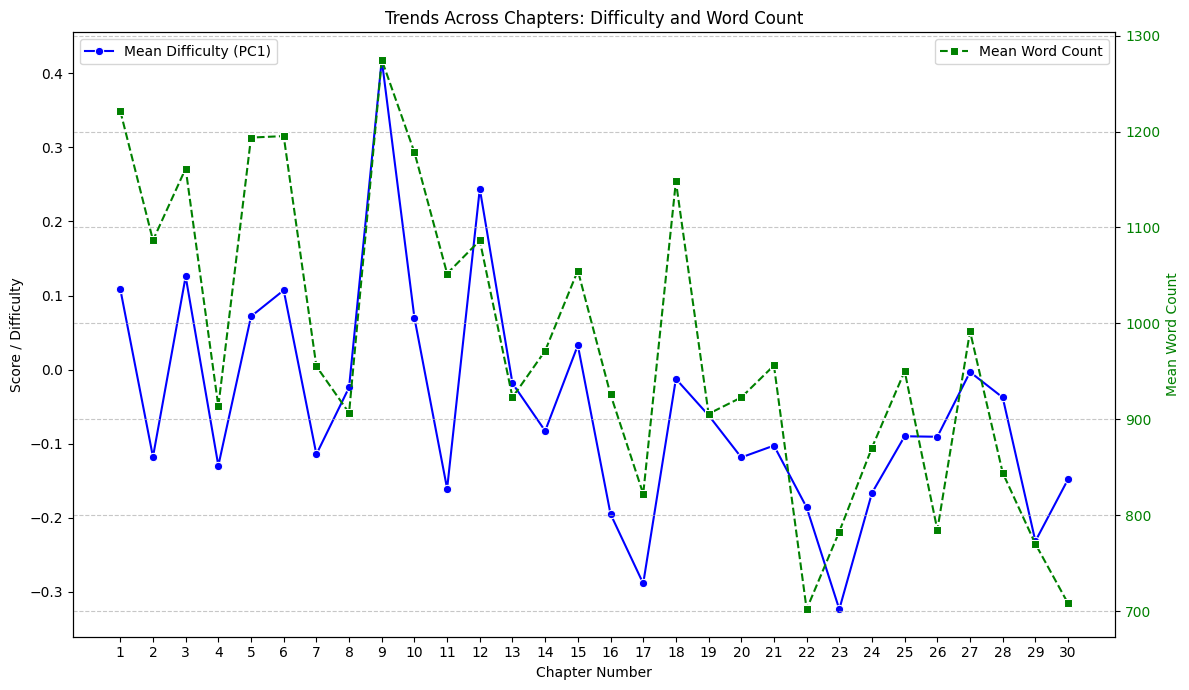

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure and a set of subplots
fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot mean difficulty and mean ACS score on the primary y-axis
sns.lineplot(x='chapter_number', y='mean_difficulty', data=chapters_summary, ax=ax1, label='Mean Difficulty (PC1)', marker='o', color='blue')

# Set labels for the primary y-axis
ax1.set_xlabel('Chapter Number')
ax1.set_ylabel('Score / Difficulty', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.legend(loc='upper left')

# Create a second y-axis for mean_word_count
ax2 = ax1.twinx()
sns.lineplot(x='chapter_number', y='mean_word_count', data=chapters_summary, ax=ax2, label='Mean Word Count', marker='s', color='green', linestyle='--')

# Set labels for the secondary y-axis
ax2.set_ylabel('Mean Word Count', color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.legend(loc='upper right')

# Set plot title
plt.title('Trends Across Chapters: Difficulty and Word Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(chapters_summary['chapter_number'].unique())
plt.tight_layout() # Adjust layout to prevent overlapping elements
plt.show()

In [ ]:
import plotly.express as px

# Create a 3D scatter plot for chapter number, mean word count, and mean difficulty
fig_topo = px.scatter_3d(
    data_frame=chapters_summary,
    x='chapter_number',
    y='mean_word_count',
    z='mean_figure_count',
    color='mean_difficulty', # Color points by difficulty for better visualization
    size='mean_word_count',  # Size points by word count to add another visual dimension
    hover_name='chapter_number', # Show chapter number on hover
    labels={
        'chapter_number': 'Chapter Number',
        'mean_word_count': 'Mean Word Count',
        'mean_figure_count': 'Mean Figure Count'
    },
    title='Trends Across Chapters, Word and Figure Counts and Net Difficulty'
)

fig_topo.update_traces(marker=dict(opacity=0.7))
fig_topo.show()

In [ ]:
#Port all graphical representations to GitHub
libretexts.info()
fig = px.scatter_3d(data_frame=libretexts, x='mean_score', y='word_count', z='figure_count', color='cluster_labels', hover_name='unit_title',
              labels={'mean_score': 'Mean ACS Score', 'word_count': 'Unit Word Count', 'figure_count': 'Unit Figure Count'})
fig.write_html('libretexts_clusters.html')
fig_new_clusters.write_html('new_clusters.html')
fig_chapter_hue.write_html('chapter_hue.html')
fig_topo.write_html('topographical_plot.html')

# Save the matplotlib plot as a PNG image
plt.savefig('chapter_trends_plot.png')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1231 entries, 0 to 1230
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   chapter_title      1231 non-null   object 
 1   unit_title         1231 non-null   object 
 2   unit_link          1231 non-null   object 
 3   specialty          1231 non-null   object 
 4   mean_score         1231 non-null   float64
 5   median_score       1231 non-null   float64
 6   word_count         1231 non-null   int64  
 7   figure_count       1231 non-null   int64  
 8   readability_score  1231 non-null   float64
 9   cluster_labels     1231 non-null   int32  
dtypes: float64(3), int32(1), int64(2), object(4)
memory usage: 91.5+ KB


<Figure size 640x480 with 0 Axes>